In [2]:
import pandas as pd 

df = pd.read_csv('sales_data_sample.csv', encoding='ISO-8859-1')

print(df)

      ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0           10107               30      95.70                2  2871.00   
1           10121               34      81.35                5  2765.90   
2           10134               41      94.74                2  3884.34   
3           10145               45      83.26                6  3746.70   
4           10159               49     100.00               14  5205.27   
...           ...              ...        ...              ...      ...   
2818        10350               20     100.00               15  2244.40   
2819        10373               29     100.00                1  3978.51   
2820        10386               43     100.00                4  5417.57   
2821        10397               34      62.24                1  2116.16   
2822        10414               47      65.52                9  3079.44   

            ORDERDATE    STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0      2/24/2003 0:00   Shipped 

In [10]:
df.drop_duplicates(inplace=True)
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,Unknown,NYC,NY,10022,USA,Unknown,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,Unknown,Reims,Not Applicable,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,Unknown,Paris,Not Applicable,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,Unknown,Pasadena,CA,90003,USA,Unknown,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,Unknown,San Francisco,CA,Unknown,USA,Unknown,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",Unknown,Madrid,Not Applicable,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,Unknown,Oulu,Not Applicable,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",Unknown,Madrid,Not Applicable,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,Unknown,Toulouse,Not Applicable,31000,France,EMEA,Roulet,Annette,Small


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

In [27]:
print(df.duplicated().sum())

0


In [28]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [6]:
df.isnull().sum()

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

In [17]:
df = df.drop(columns=['ADDRESSLINE2'])

df['STATE'] = df['STATE'].fillna('Not Applicable')

df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')

df['POSTALCODE'] = df['POSTALCODE'].fillna('Unknown')



KeyError: "['ADDRESSLINE2'] not found in axis"

In [8]:
df['STATUS'] = df['STATUS'].str.strip()
df['PRODUCTLINE'] = df['PRODUCTLINE'].str.strip()
df['DEALSIZE'] = df['DEALSIZE'].str.strip()

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

PRODUCTLINE
Classic Cars        3919615.66
Motorcycles         1166388.34
Planes               975003.57
Ships                714437.13
Trains               226243.47
Trucks and Buses    1127789.84
Vintage Cars        1903150.84
Name: SALES, dtype: float64


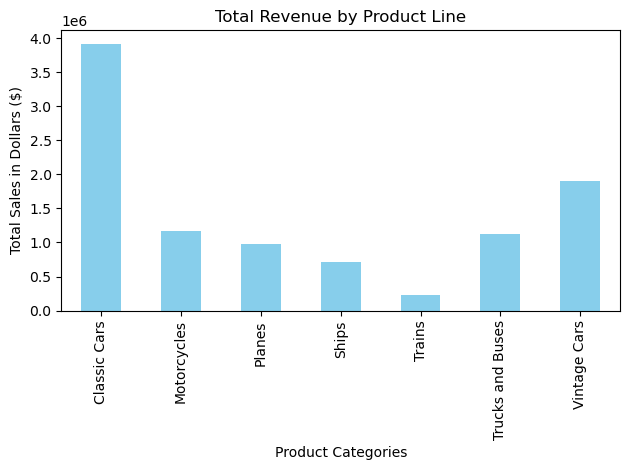

In [25]:




product_revenue = df.groupby('PRODUCTLINE')['SALES'].sum()
print(product_revenue)

product_revenue.plot(kind='bar', color='skyblue')


plt.title('Total Revenue by Product Line')
plt.xlabel('Product Categories')
plt.ylabel('Total Sales in Dollars ($)')

plt.tight_layout()
plt.show()

COUNTRY
Australia       630623.10
Austria         202062.53
Belgium         108412.62
Canada          224078.56
Denmark         245637.15
Finland         329581.91
France         1110916.52
Germany         220472.09
Ireland          57756.43
Italy           374674.31
Japan           188167.81
Norway          307463.70
Philippines      94015.73
Singapore       288488.41
Spain          1215686.92
Sweden          210014.21
Switzerland     117713.56
UK              478880.46
USA            3627982.83
Name: SALES, dtype: float64


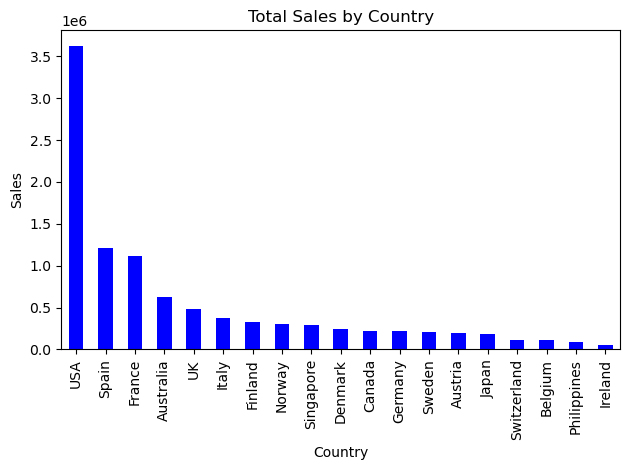

In [35]:
countrys_by_Product = df.groupby('COUNTRY')['SALES'].sum()
print(countrys_by_Product)

countrys_by_Product = countrys_by_Product.sort_values(ascending=False)


countrys_by_Product.plot(kind='bar' , color='blue')


plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

DEALSIZE
Large     1302119.26
Medium    6087432.24
Small     2643077.35
Name: SALES, dtype: float64


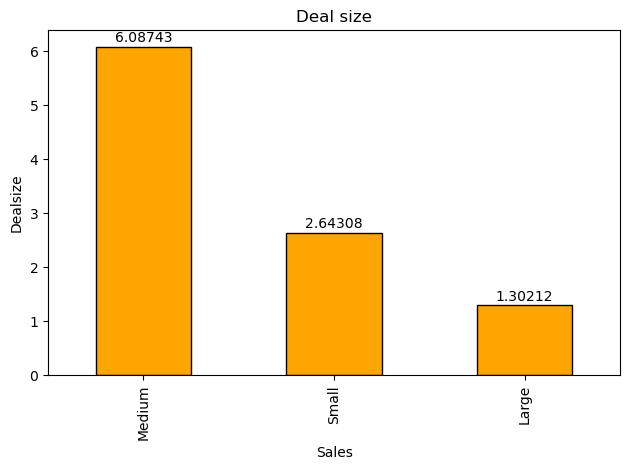

In [16]:
Deal_size = df.groupby('DEALSIZE')['SALES'].sum()
print(Deal_size)

Deal_size = Deal_size.sort_values(ascending=False)

Deal_size_millions = Deal_size / 1000000

ax = Deal_size_millions.plot(kind ='bar' , color ='orange' ,  edgecolor = 'black')

ax.bar_label(ax.containers[0], padding=1)

plt.title('Deal size')
plt.xlabel('Sales')
plt.ylabel('Dealsize')

plt.tight_layout()
plt.show()

STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64


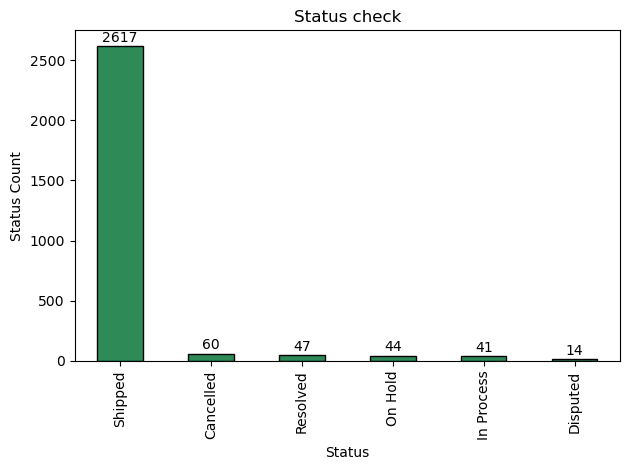

In [13]:
status_counts = df['STATUS'].value_counts()
print(status_counts)


ax = status_counts.plot(kind ='bar' , color ='seagreen' ,  edgecolor = 'black')

ax.bar_label(ax.containers[0], padding=1)

plt.title('Status check')
plt.xlabel('Status')
plt.ylabel('Status Count')

plt.tight_layout()
plt.show()

In [17]:
months_per_year = df.groupby('YEAR_ID')['MONTH_ID'].nunique()
print(months_per_year)

YEAR_ID
2003    12
2004    12
2005     5
Name: MONTH_ID, dtype: int64


YEAR_ID
2003    3516979.54
2004    4724162.60
2005    1791486.71
Name: SALES, dtype: float64


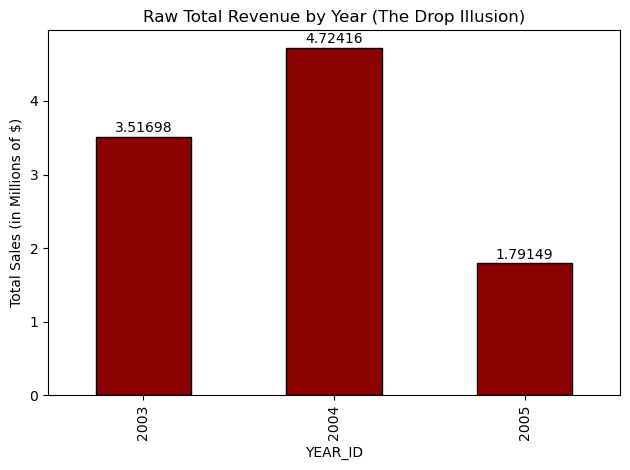

In [20]:
yearly_sales = df.groupby('YEAR_ID')['SALES'].sum()

print(yearly_sales)

yearly_sales_millions = yearly_sales / 1000000

ax = yearly_sales_millions.plot(kind='bar', color='darkred', edgecolor='black')

ax.bar_label(ax.containers[0], padding=1)

plt.title('Raw Total Revenue by Year (The Drop Illusion)')
plt.ylabel('Total Sales (in Millions of $)')
plt.tight_layout()"data cleaning.ipynb"
plt.show()

<Axes: xlabel='MONTH_ID'>

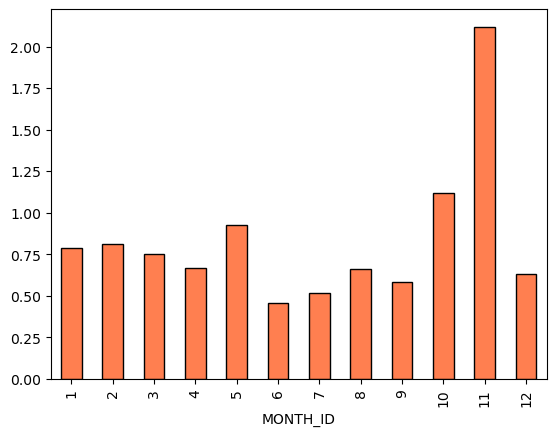

In [23]:

monthly_sales = df.groupby('MONTH_ID')['SALES'].sum()

monthly_sales_millions = monthly_sales / 1000000

monthly_sales_millions.plot(kind='bar', color='coral', edgecolor='black')



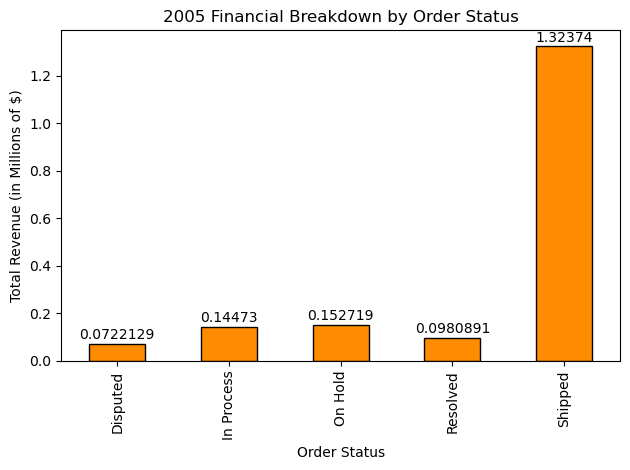

In [26]:
df_2005 = df[df['YEAR_ID'] == 2005]

status_sales_2005 = df_2005.groupby('STATUS')['SALES'].sum()

status_sales_millions = status_sales_2005 / 1000000

ax = status_sales_millions.plot(kind='bar', color='darkorange', edgecolor='black')

ax.bar_label(ax.containers[0], padding=1)

plt.title('2005 Financial Breakdown by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Revenue (in Millions of $)')

plt.tight_layout()
plt.show()